In [23]:
import warnings

from ipywidgets import IntSlider

from ds_notes.notebooks.pandas_merge import data_path

warnings.filterwarnings("ignore")

In [10]:
import pandas as pd
import drawdata
import matplotlib.pyplot as plt

In [4]:
widget = drawdata.ScatterWidget()
widget

In [6]:
data = widget.data_as_pandas

In [7]:
data.head()

,x,y,color,label,batch
0,103.351710,102.528526,#1f77b4,a,0
1,84.046732,72.197580,#1f77b4,a,0
2,65.961825,115.062339,#1f77b4,a,0
3,90.256652,126.252999,#1f77b4,a,0
4,91.719113,177.977954,#1f77b4,a,0


In [8]:
data.to_csv("datasets/simple.csv", index=False)

<Axes: >

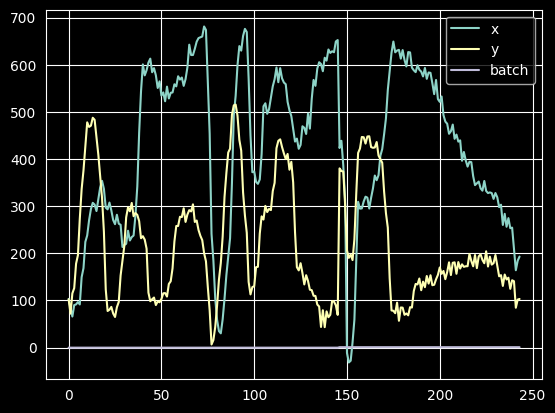

In [9]:
data.plot()

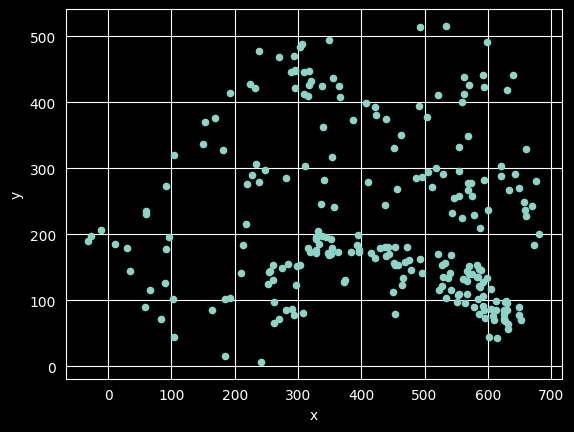

In [12]:
fig, ax = plt.subplots()
data.plot.scatter(x="x", y="y", ax=ax)

plt.show()

# Explore Bagging

6 different random forest with single tree


In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

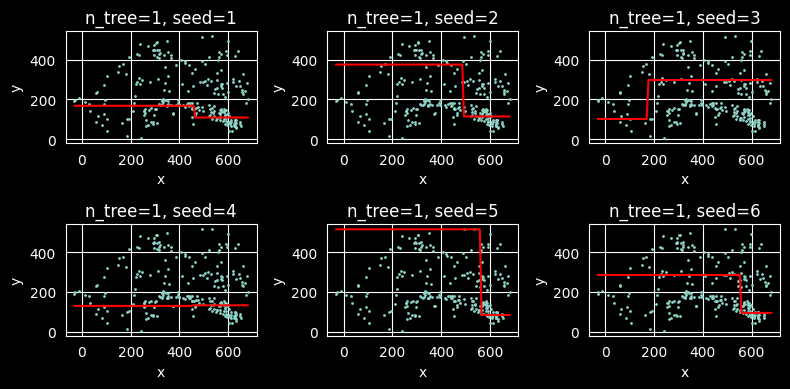

In [21]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1] * 6

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}, seed={i}", s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=i)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })
    y = clf.predict(x)
    ax.plot(x, y, c="red")

fig.tight_layout()


## random forest vs single tree
- przykład dlaczego random forest minimalizuje overfiting

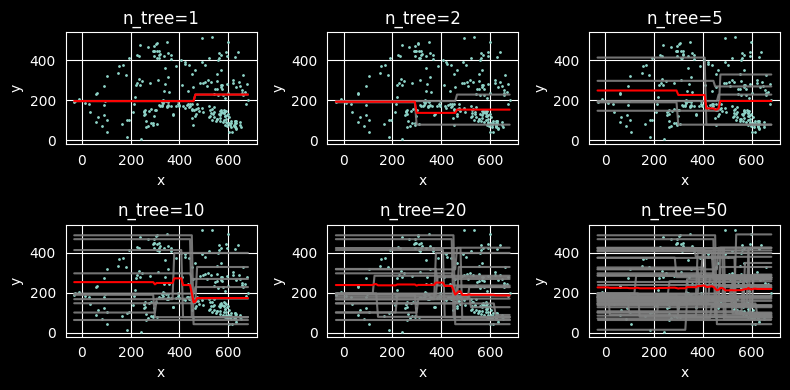

In [25]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

    clf = RandomForestRegressor(n_estimators=n_tree, max_depth=3, max_samples=0.01, random_state=42)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })

    for i, tree in enumerate(clf.estimators_):
        y = tree.predict(x)
        ax.plot(x, y, c="grey", alpha=0.9)

    y = clf.predict(x)
    ax.plot(x, y, c="red")

fig.tight_layout()


In [30]:
def plot_random_forest(data_path, max_depth, max_samples):
    layouts = """
    123
    4456
    """
    plt.close('all')

    fig, axs = plt.subplot_mosaic(layouts, figsize=(18, 4))
    n_trees = [1, 2, 5, 10, 20, 50]

    data = pd.read_csv(data_path)

    for i, n_tree in enumerate(n_trees, start=1):
        ax = axs[str(i)]
        data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

        clf = RandomForestRegressor(n_estimators=n_tree, max_depth=max_depth, max_samples=max_samples, random_state=42)
        clf.fit(data[["x"]], data["y"])

        x = pd.DataFrame({
            "x": np.linspace(data.x.min(), data.x.max(), 100),
        })

        for i, tree in enumerate(clf.estimators_):
            y = tree.predict(x)
            ax.plot(x, y, c="grey", alpha=0.9)

        y = clf.predict(x)
        ax.plot(x, y, c="red")

    fig.tight_layout()
    plt.show()

In [37]:
from ipywidgets import FloatSlider, IntSlider, interact

max_depth_slider = IntSlider(min=1, max=3, step=1, value=3, description="Max Depth")
max_samples_slider = FloatSlider(min=0.01, max=1.0, step=0.01, value=0.1, description="Max Samples")

interact(
    plot_random_forest,
    data_path = "datasets/simple.csv",
    max_depth = max_depth_slider,
    max_samples = max_samples_slider,
)


interactive(children=(Text(value='datasets/simple.csv', description='data_path'), IntSlider(value=3, descripti…

<Figure size 1800x400 with 0 Axes>

---


In [33]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from sklearn import set_config

In [34]:
set_config(transform_output="pandas")

In [43]:
adult_data = fetch_openml(data_id=1590)
X = adult_data.data
y = adult_data.target

In [45]:
(
    X
    .assign(y=y)
    .to_parquet("datasets/adult_copy.parquet")
)

In [46]:
X.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [51]:
categorical_features = X.select_dtypes(include=["category"]).columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [52]:
categorical_transformer.fit_transform(X[categorical_features])

,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_missing,education_10th,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,native-country_missing
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48838,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48839,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
48840,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43, stratify=y)

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, max_depth=20, max_samples=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.832


In [79]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

param_distributions = {
    "classifier__n_estimators": np.arange(50, 801, 50),
    "classifier__max_depth": [None, 3, 5, 8, 12, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 8],
    "classifier__max_features": ["sqrt", "log2", None],
}

rnd = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

rnd.fit(X_train, y_train)

print("Best params:", rnd.best_params_)
print("Best CV accuracy:", rnd.best_score_)

y_pred = rnd.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

pd.DataFrame(rnd.cv_results_).sort_values("rank_test_score").head(10)[
    ["mean_test_score", "std_test_score", "mean_train_score", "params"]
]

KeyboardInterrupt: 

In [80]:
# Boosting and Gradient Boosting

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression

import warnings

warnings.filterwarnings("ignore")

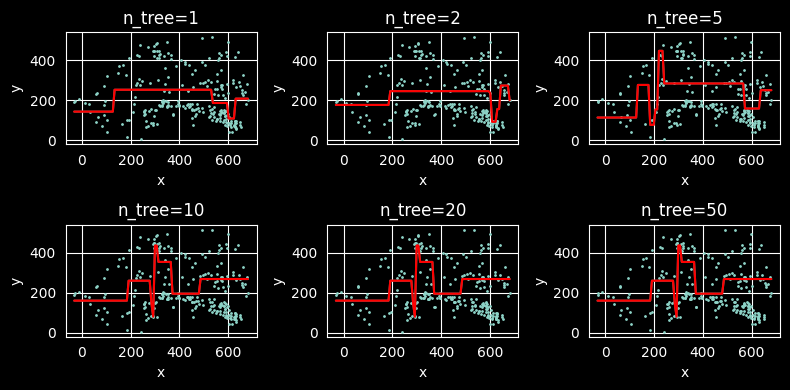

In [85]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

    clf = AdaBoostRegressor(n_estimators=n_tree,estimator=DecisionTreeRegressor(max_depth=3), random_state=42)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_[-1].predict(x)
    ax.plot(x, y, c="grey", alpha=0.9)

    ax.plot(x, y, c="red")

fig.tight_layout()

In [86]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


In [87]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, categorical_features)
    ]
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, max_depth=20, max_samples=0.1, random_state=42))
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.832


# Gradient boosting


In [89]:
from sklearn.ensemble import GradientBoostingRegressor

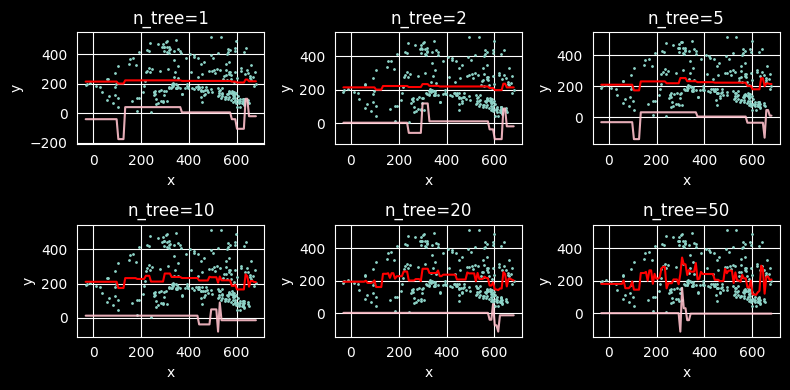

In [96]:
layout = """
123
456
"""

fig, axs = plt.subplot_mosaic(layout, figsize=(8, 4))
n_trees = [1, 2, 5, 10, 20, 50]

data = pd.read_csv("datasets/simple.csv")

for i, n_tree in enumerate(n_trees, start=1):
    ax = axs[str(i)]
    data.plot.scatter(x="x", y="y", ax=ax, title=f"n_tree={n_tree}", s=1)

    clf = GradientBoostingRegressor(n_estimators=n_tree, max_depth=3, random_state=42)
    clf.fit(data[["x"]], data["y"])

    x = pd.DataFrame({
        "x": np.linspace(data.x.min(), data.x.max(), 100),
    })

    y = clf.estimators_.flatten()[-1].predict(x)
    ax.plot(x, y, c="pink", alpha=0.9)
    y=clf.predict(x)
    ax.plot(x, y, c="red")

fig.tight_layout()

In [98]:
from sklearn.ensemble import GradientBoostingClassifier

In [99]:

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier())
])

pipeline.fit(X_train, y_train)

accuracy = accuracy_score(y_test, pipeline.predict(X_test))
print(f"Model Accuracy: {accuracy:.3f}")

Model Accuracy: 0.833
